# Assignment 2: Data Quality Assessment and Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

In [2]:
df = pd.read_csv("laptop_price.csv", encoding="latin-1")
df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


## Task 1: Identify Data Quality Issues

In [3]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
laptop_ID           0
Company             0
Product             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price_euros         0
dtype: int64


In [4]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [5]:
print(df.dtypes)

laptop_ID             int64
Company              object
Product              object
TypeName             object
Inches              float64
ScreenResolution     object
Cpu                  object
Ram                  object
Memory               object
Gpu                  object
OpSys                object
Weight               object
Price_euros         float64
dtype: object


In [6]:
print("Dataset Shape:", df.shape)

Dataset Shape: (1303, 13)


### Findings

- No missing values were found in the dataset.
- No duplicate records were detected.
- Several columns are stored as categorical or text data, such as Company, CPU, RAM, Memory, GPU, and Operating System.
- The dataset contains 1303 rows and 13 columns.
- RAM and Weight are stored as text values and may require conversion into numerical format before further analysis.

## Task 2: Missing Value Handling

In [7]:
print(df.isnull().sum().sum())

0


### Missing Value Strategy

The dataset does not contain any missing values. Therefore, no imputation technique was required.

If missing values were present, mean imputation would be applied to numerical features because it preserves the overall distribution and is simple to implement.

## Task 3: Outlier Detection using IQR

In [8]:
df['Ram'] = df['Ram'].str.replace('GB', '').astype(int)

df['Weight'] = df['Weight'].str.replace('kg', '').astype(float)

Q1 = df['Price_euros'].quantile(0.25)
Q3 = df['Price_euros'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Price_euros'] < lower_bound) |
              (df['Price_euros'] > upper_bound)]

print("Number of outliers:", len(outliers))

Number of outliers: 29


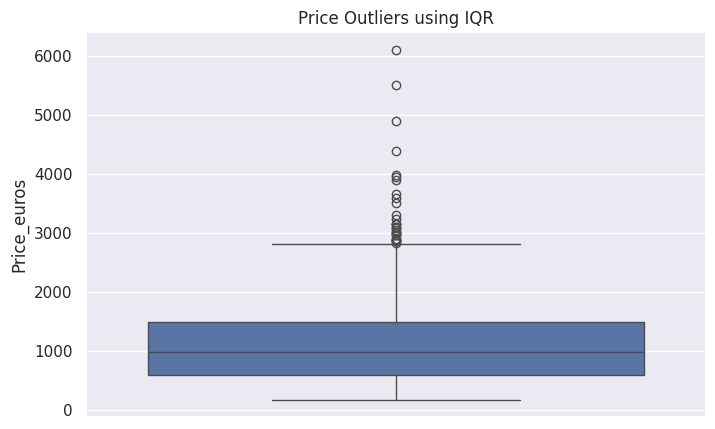

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(y=df['Price_euros'])

plt.title("Price Outliers using IQR")
plt.show()

### Results

Using the IQR method, 29 outliers were detected in the Price_euros column.

These outliers correspond to very expensive laptops. Since they represent real products rather than data entry errors, they were retained in the dataset.

## Task 4: Feature Normalization

In [10]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

numerical_features = ['Inches', 'Ram', 'Weight', 'Price_euros']

minmax_scaler = MinMaxScaler()
zscore_scaler = StandardScaler()

df_minmax = pd.DataFrame(
    minmax_scaler.fit_transform(df[numerical_features]),
    columns=numerical_features
)

df_zscore = pd.DataFrame(
    zscore_scaler.fit_transform(df[numerical_features]),
    columns=numerical_features
)

print("Min-Max Normalization")
display(df_minmax.head())

print("Z-Score Normalization")
display(df_zscore.head())

Min-Max Normalization


,Inches,Ram,Weight,Price_euros
0,0.385542,0.096774,0.169576,0.196741
1,0.385542,0.096774,0.162095,0.122353
2,0.662651,0.096774,0.291771,0.067679
3,0.638554,0.225806,0.284289,0.398895
4,0.385542,0.096774,0.169576,0.275038


Z-Score Normalization


,Inches,Ram,Weight,Price_euros
0,-1.204407,-0.075195,-1.005283,0.309132
1,-1.204407,-0.075195,-1.050381,-0.321646
2,0.408772,-0.075195,-0.268684,-0.785251
3,0.268495,1.498767,-0.313782,2.023301
4,-1.204407,-0.075195,-1.005283,0.973055


## Task 5: Principal Component Analysis (PCA)

In [11]:
from sklearn.decomposition import PCA

features = ['Inches', 'Ram', 'Weight', 'Price_euros']

pca = PCA()

pca.fit(df_zscore)

explained_variance = pca.explained_variance_ratio_

for i, variance in enumerate(explained_variance):
    print(f"PC{i+1}: {variance:.4f}")

PC1: 0.5625
PC2: 0.3387
PC3: 0.0593
PC4: 0.0394


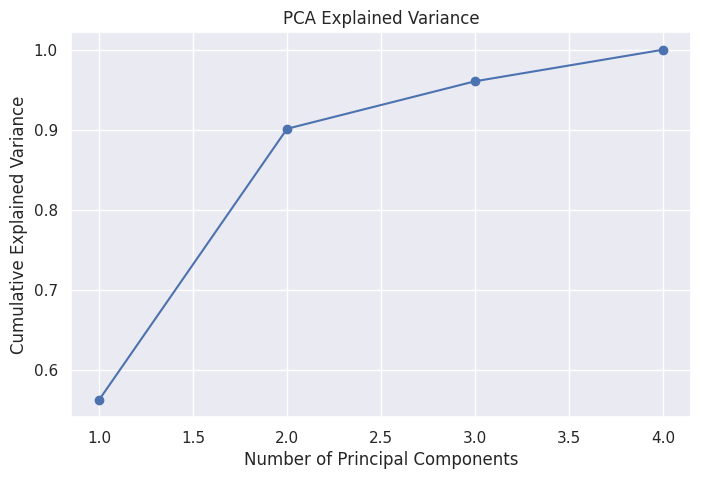

In [12]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(explained_variance)+1),
    explained_variance.cumsum(),
    marker='o'
)

plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')

plt.grid(True)

plt.show()

### PCA Interpretation

PCA was applied to the normalized numerical features (Inches, Ram, Weight, and Price_euros).

The first principal component (PC1) explains 56.25% of the total variance in the dataset, while the second principal component (PC2) explains 33.87%.

Together, PC1 and PC2 explain approximately 90.12% of the total variance, indicating that most of the information in the dataset can be represented using only two principal components.

The remaining components contribute relatively little information, with PC3 explaining 5.93% and PC4 explaining 3.94% of the variance.

Based on the cumulative explained variance plot, dimensionality reduction to two principal components would preserve most of the dataset information while reducing complexity.